Este módulo final representa el núcleo analítico de integración del sistema, donde se consolidaron las cinco variables espaciales en el Índice de Aptitud Eólica definitivo.

Para asegurar la pulcritud cartográfica, se resolvió el Problema Técnico 2 mediante la declaración explícita del parámetro nodata=-9999 dentro de las funciones de enmascaramiento de rasterio.mask(), neutralizando los píxeles espurios rellenados con ceros en los bordes costeros fragmentados.

Posteriormente, el área de estudio se delimitó estrictamente sobre la Planicie Magallánica y la Tierra del Fuego chilena.

La variable ambiental provista por el SNASPE se integró bajo una lógica de exclusión absoluta , operando como una máscara booleana que fuerza a cero la aptitud de cualquier celda intersectada por un área protegida, independientemente de su calidad de recurso eólico.

Finalmente, se ejecutó un algoritmo de álgebra de mapas basado en una suma ponderada lineal según los pesos validados por criterio experto (35% viento, 20% pendiente, 20% áreas protegidas, 15% uso de suelo y 10% red eléctrica), exportando el producto maestro continuo $[0, 1]$ en un formato GeoTIFF de alta fidelidad (aptitud_final.tif).

Cabe recalcar que inicialmente el código paso por las fases de nacional a regional a finalmente local, se fue cambiando debido a las limitaciones del programa, en esta parte final se decidió mapear la planicie de la Región de Magallanes, a diferencia de la región como se esperaba inicialmente, por lo que todos los rasters y variables guardados en drive, se terminaron por recortar al área de estudio aquí.

In [3]:
# CELDA 1 — Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# CELDA 2 — Verificar RAM
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       8.2Gi       2.0Mi       3.3Gi        11Gi
Swap:             0B          0B          0B


In [5]:
# CELDA 3 — Obtener ambas provincias vía GEE (nivel 2 = provincia)
import ee
ee.Authenticate()
ee.Initialize(project='geoandres')

gaul = ee.FeatureCollection("FAO/GAUL/2015/level2")

planicie = gaul.filter(
    ee.Filter.And(
        ee.Filter.eq('ADM0_NAME', 'Chile'),
        ee.Filter.Or(
            ee.Filter.stringContains('ADM2_NAME', 'Magallanes'),
            ee.Filter.stringContains('ADM2_NAME', 'Tierra del Fuego')
        )
    )
)

print("Provincias encontradas:", planicie.aggregate_array('ADM2_NAME').getInfo())

geom_planicie_simple = planicie.geometry().simplify(maxError=300)

task = ee.batch.Export.table.toDrive(
    collection=ee.FeatureCollection([ee.Feature(geom_planicie_simple)]),
    description='limite_planicie_magallanes',
    folder='GEO3211_Eolico',
    fileFormat='GeoJSON'
)
task.start()
print("🚀 Exportando límite combinado...")

Provincias encontradas: ['Magallanes', 'Tierra del Fuego']
🚀 Exportando límite combinado...


In [6]:
# CELDA 4 — Monitorear
import time
while task.active():
    print(task.status()['state'])
    time.sleep(15)
print("Final:", task.status())

READY
RUNNING
RUNNING
RUNNING
RUNNING
Final: {'state': 'COMPLETED', 'description': 'limite_planicie_magallanes', 'priority': 100, 'creation_timestamp_ms': 1782237176827, 'update_timestamp_ms': 1782237248443, 'start_timestamp_ms': 1782237182002, 'task_type': 'EXPORT_FEATURES', 'destination_uris': ['https://drive.google.com/#folders/1HjSt3lrio4NleCiLuWp7QMvWc2w-OAFS'], 'attempt': 1, 'batch_eecu_usage_seconds': 94.14324188232422, 'id': 'W4LD3XHRUDQWUGHKQNOAESRR', 'name': 'projects/geoandres/operations/W4LD3XHRUDQWUGHKQNOAESRR'}


<Axes: >

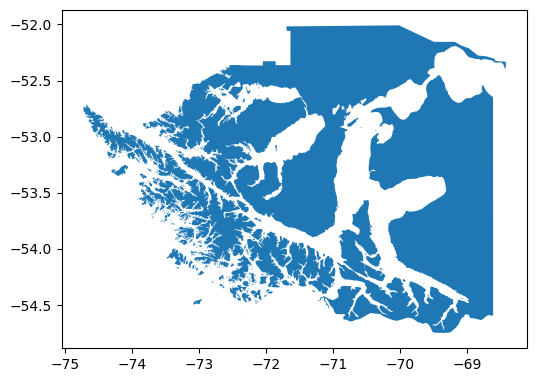

In [7]:
# CELDA 5 — Leer y limpiar (mismo patrón ya probado)
import geopandas as gpd
from shapely.ops import unary_union

carpeta = '/content/drive/MyDrive/GEO3211_Eolico'
raw = gpd.read_file(f'{carpeta}/limite_planicie_magallanes.geojson')
explotado = raw.explode(index_parts=False)
limpio = explotado[explotado.geometry.type.isin(['Polygon', 'MultiPolygon'])]

planicie_final = gpd.GeoDataFrame(
    {'region': ['Planicie Magallanes-TdF']},
    geometry=[unary_union(limpio.geometry)],
    crs=limpio.crs
)
planicie_final.to_file(f'{carpeta}/planicie_limite.shp')
planicie_final.plot(figsize=(6, 9))

In [8]:
# ============================================================
# Recortar VIENTO a la planicie combinada
# ============================================================
import rasterio
from rasterio.mask import mask

planicie_4326 = planicie_final.to_crs('EPSG:4326')
geom_planicie_4326 = [planicie_4326.geometry.iloc[0].__geo_interface__]

with rasterio.open(f'{carpeta}/viento_medio_1996_2026.tif') as src:
    viento_planicie, transform_v = mask(src, geom_planicie_4326, crop=True, nodata=-9999, filled=True)
    perfil_v = src.profile.copy()
    perfil_v.update({'height': viento_planicie.shape[1], 'width': viento_planicie.shape[2],
                      'transform': transform_v, 'nodata': -9999})

with rasterio.open(f'{carpeta}/viento_planicie.tif', 'w', **perfil_v) as dst:
    dst.write(viento_planicie)
print("✅ Viento recortado a la planicie")

✅ Viento recortado a la planicie


In [9]:
# ============================================================
# Recortar PENDIENTE a la planicie combinada
# ============================================================
planicie_utm = planicie_final.to_crs('EPSG:32719')
geom_planicie_utm = [planicie_utm.geometry.iloc[0].__geo_interface__]

with rasterio.open(f'{carpeta}/pendiente_grados_90m_UNIFICADO.tif') as src:
    pendiente_planicie, transform_p = mask(src, geom_planicie_utm, crop=True, nodata=-9999, filled=True)
    perfil_p = src.profile.copy()
    perfil_p.update({'height': pendiente_planicie.shape[1], 'width': pendiente_planicie.shape[2],
                       'transform': transform_p, 'nodata': -9999})

with rasterio.open(f'{carpeta}/pendiente_planicie.tif', 'w', **perfil_p) as dst:
    dst.write(pendiente_planicie)
print("✅ Pendiente recortada a la planicie")

✅ Pendiente recortada a la planicie


In [ ]:
# ============================================================
# Verificación rápida
# ============================================================
import numpy as np

with rasterio.open(f'{carpeta}/viento_planicie.tif') as src:
    v = src.read(1); v = np.where(v==src.nodata, np.nan, v)
print(f"Viento - media: {np.nanmean(v):.2f} m/s, max: {np.nanmax(v):.2f}")

with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as src:
    p = src.read(1); p = np.where(p==src.nodata, np.nan, p)
print(f"Pendiente - media: {np.nanmean(p):.2f}°, max: {np.nanmax(p):.2f}°")

Viento - media: 3.80 m/s, max: 8.24
Pendiente - media: 10.21°, max: 73.59°


In [10]:
# ============================================================
# Cargar uso de suelo de Magallanes y recortar a la planicie combinada
# ============================================================
import gc

uso_suelo_magallanes = gpd.read_file(f'{carpeta}/uso_suelo_magallanes_unificado.shp')
print(f"Cargado: {len(uso_suelo_magallanes)} polígonos")

# Simplificar ANTES del clip — más agresivo que con TdF sola, dado el mayor volumen
uso_suelo_magallanes['geometry'] = uso_suelo_magallanes.geometry.simplify(
    tolerance=50, preserve_topology=True
)
print("✅ Geometrías simplificadas")

Cargado: 286529 polígonos


KeyboardInterrupt: 

In [11]:
# ============================================================
# Pre-filtrar por bounding box antes del clip fino (más rápido)
# ============================================================
bounds = planicie_utm.total_bounds
candidatos = uso_suelo_magallanes.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

del uso_suelo_magallanes
gc.collect()

print(f"Candidatos tras filtro de bounding box: {len(candidatos)}")

Candidatos tras filtro de bounding box: 147458


In [12]:
# ============================================================
# Clip fino sobre el subconjunto ya reducido
# ============================================================
uso_suelo_planicie = gpd.clip(candidatos, planicie_utm)

del candidatos
gc.collect()

print(f"✅ Polígonos en la planicie: {len(uso_suelo_planicie)}")

✅ Polígonos en la planicie: 114226


In [ ]:
# ============================================================
# Guardar de inmediato (antes de hacer cualquier otra cosa)
# ============================================================
uso_suelo_planicie.to_file(f'{carpeta}/uso_suelo_planicie.shp')
print("💾 Guardado: uso_suelo_planicie.shp")

💾 Guardado: uso_suelo_planicie.shp


In [ ]:
# ============================================================
# Aplicar tabla de aptitud a uso_suelo_planicie
# ============================================================
tabla_aptitud = {
    'Áreas Desprovistas de Vegetación': 5,
    'Praderas y Matorrales':            4,
    'Terrenos Agrícolas':               2,
    'Bosques':                          1,
    'Humedales':                        0,
    'Cuerpos de Agua':                  0,
    'Áreas Urbanas e Industriales':     0,
    'Nieves Eternas y Glaciares':       0,
    'Áreas no Reconocidas':             0,
}

uso_suelo_planicie['APTITUD_USO'] = uso_suelo_planicie['USO'].map(tabla_aptitud)

sin_mapear = uso_suelo_planicie['APTITUD_USO'].isna().sum()
print(f"Polígonos sin aptitud asignada: {sin_mapear}")
print(uso_suelo_planicie['APTITUD_USO'].value_counts(dropna=False).sort_index())

Polígonos sin aptitud asignada: 0
APTITUD_USO
0    20351
1    35315
2      887
4    44039
5    13449
Name: count, dtype: int64


In [ ]:
# ============================================================
# Rasterizar usando pendiente_planicie.tif como grilla de referencia
# ============================================================
from rasterio.features import rasterize
import numpy as np

with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as ref:
    perfil_ref = ref.profile.copy()
    shape_ref = (ref.height, ref.width)
    transform_ref = ref.transform

formas_valores = [
    (geom, valor)
    for geom, valor in zip(uso_suelo_planicie.geometry, uso_suelo_planicie['APTITUD_USO'])
]

uso_suelo_raster_planicie = rasterize(
    formas_valores, out_shape=shape_ref, transform=transform_ref,
    fill=-9999, dtype='float32'
)

print(f"✅ Raster generado: {uso_suelo_raster_planicie.shape}")

✅ Raster generado: (3382, 4739)


In [ ]:
# ============================================================
# Guardar de inmediato
# ============================================================
perfil_uso = perfil_ref.copy()
perfil_uso.update({'nodata': -9999, 'dtype': 'float32'})

with rasterio.open(f'{carpeta}/aptitud_uso_suelo_planicie.tif', 'w', **perfil_uso) as dst:
    dst.write(uso_suelo_raster_planicie, 1)

print("💾 Guardado: aptitud_uso_suelo_planicie.tif")

💾 Guardado: aptitud_uso_suelo_planicie.tif


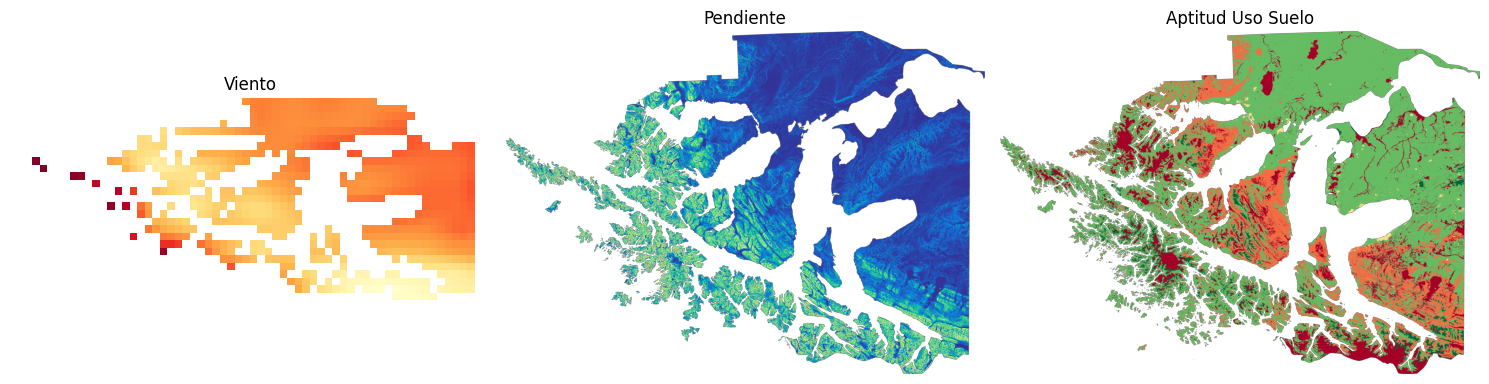

In [ ]:
# ============================================================
# Visualizar las 3 variables juntas
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 8))

with rasterio.open(f'{carpeta}/viento_planicie.tif') as src:
    v = src.read(1); v = np.where(v==src.nodata, np.nan, v)
axes[0].imshow(v, cmap='YlOrRd'); axes[0].set_title('Viento'); axes[0].axis('off')

with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as src:
    p = src.read(1); p = np.where(p==src.nodata, np.nan, p)
axes[1].imshow(p, cmap='terrain'); axes[1].set_title('Pendiente'); axes[1].axis('off')

u = np.where(uso_suelo_raster_planicie==-9999, np.nan, uso_suelo_raster_planicie)
axes[2].imshow(u, cmap='RdYlGn', vmin=0, vmax=5); axes[2].set_title('Aptitud Uso Suelo'); axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'{carpeta}/planicie_tres_variables.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Cargar uso de suelo de la planicie (ya recortado) y revisar TIPO_SNASP
# ============================================================
import geopandas as gpd

uso_suelo_planicie = gpd.read_file(f'{carpeta}/uso_suelo_planicie.shp')

print("Valores en TIPO_SNASP:")
print(uso_suelo_planicie['TIPO_SNASP'].value_counts(dropna=False))

Valores en TIPO_SNASP:
TIPO_SNASP
None                 57980
Parque Nacional      55337
Reserva Nacional       712
Monumento Natural       12
Name: count, dtype: int64


In [ ]:
# ============================================================
# Tabla de aptitud para áreas protegidas
# Estar protegido = no apto para parque eólico (restricción legal/ambiental)
# ============================================================
tabla_aptitud_snasp = {
    'Parque Nacional':    0,   # máxima protección, no apto
    'Reserva Nacional':   0,   # protegido, no apto
    'Monumento Natural':  0,   # protegido, no apto
    None:                 5,   # sin restricción SNASPE, apto según esta variable
}

uso_suelo_planicie['APTITUD_SNASP'] = uso_suelo_planicie['TIPO_SNASP'].map(tabla_aptitud_snasp)

print(uso_suelo_planicie['APTITUD_SNASP'].value_counts(dropna=False))

APTITUD_SNASP
5    57980
0    56061
Name: count, dtype: int64


In [ ]:
# ============================================================
# Rasterizar usando pendiente_planicie.tif como referencia
# ============================================================
import rasterio
from rasterio.features import rasterize
import numpy as np

with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as ref:
    perfil_ref = ref.profile.copy()
    shape_ref = (ref.height, ref.width)
    transform_ref = ref.transform

formas_valores = [
    (geom, valor)
    for geom, valor in zip(uso_suelo_planicie.geometry, uso_suelo_planicie['APTITUD_SNASP'])
]

aptitud_snasp_raster = rasterize(
    formas_valores, out_shape=shape_ref, transform=transform_ref,
    fill=-9999, dtype='float32'
)

print(f"✅ Raster generado: {aptitud_snasp_raster.shape}")

✅ Raster generado: (3382, 4739)


In [ ]:
# ============================================================
# Guardar
# ============================================================
perfil_snasp = perfil_ref.copy()
perfil_snasp.update({'nodata': -9999, 'dtype': 'float32'})

with rasterio.open(f'{carpeta}/aptitud_snasp_planicie.tif', 'w', **perfil_snasp) as dst:
    dst.write(aptitud_snasp_raster, 1)

print("💾 Guardado: aptitud_snasp_planicie.tif")

💾 Guardado: aptitud_snasp_planicie.tif


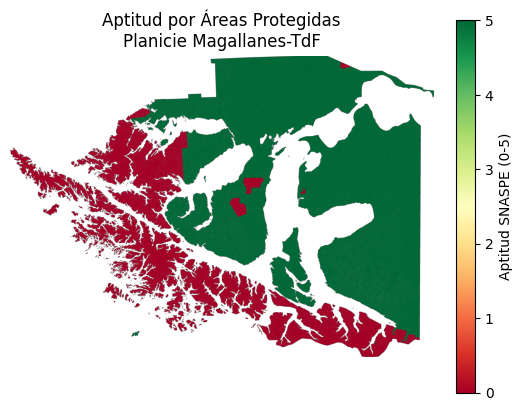

In [ ]:
# ============================================================
# Visualizar
# ============================================================
import matplotlib.pyplot as plt

u = np.where(aptitud_snasp_raster == -9999, np.nan, aptitud_snasp_raster)

fig, ax = plt.subplots(figsize=(6, 9))
im = ax.imshow(u, cmap='RdYlGn', vmin=0, vmax=5)
plt.colorbar(im, ax=ax, fraction=0.04, label='Aptitud SNASPE (0-5)')
ax.set_title('Aptitud por Áreas Protegidas\nPlanicie Magallanes-TdF')
ax.axis('off')
plt.savefig(f'{carpeta}/aptitud_snasp_mapa.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Verificar que todas las capas tengan el mismo shape y transform
# ============================================================
import rasterio

archivos = {
    'viento': f'{carpeta}/viento_planicie.tif',
    'pendiente': f'{carpeta}/pendiente_planicie.tif',
    'uso_suelo': f'{carpeta}/aptitud_uso_suelo_planicie.tif',
    'red_electrica': f'{carpeta}/aptitud_red_electrica_planicie.tif',
    'snaspe': f'{carpeta}/aptitud_snasp_planicie.tif',
}

for nombre, ruta in archivos.items():
    with rasterio.open(ruta) as src:
        print(f"{nombre}: shape={src.shape}, transform={src.transform[0]:.1f}m, crs={src.crs}")

viento: shape=(28, 64), transform=0.1m, crs=EPSG:4326
pendiente: shape=(3382, 4739), transform=90.0m, crs=EPSG:32719
uso_suelo: shape=(3382, 4739), transform=90.0m, crs=EPSG:32719
red_electrica: shape=(3382, 4739), transform=90.0m, crs=EPSG:32719
snaspe: shape=(3382, 4739), transform=90.0m, crs=EPSG:32719


In [ ]:
# ============================================================
# Remuestrear viento a la grilla común (90m, EPSG:32719)
# usando pendiente como plantilla de referencia
# ============================================================
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as ref:
    perfil_ref = ref.profile.copy()
    shape_ref = (ref.height, ref.width)
    transform_ref = ref.transform
    crs_ref = ref.crs

with rasterio.open(f'{carpeta}/viento_planicie.tif') as src:
    viento_data = src.read(1)
    viento_transform = src.transform
    viento_crs = src.crs
    viento_nodata = src.nodata

    viento_remuestreado = np.empty(shape_ref, dtype='float32')

    reproject(
        source=viento_data,
        destination=viento_remuestreado,
        src_transform=viento_transform,
        src_crs=viento_crs,
        src_nodata=viento_nodata,
        dst_transform=transform_ref,
        dst_crs=crs_ref,
        dst_nodata=-9999,
        resampling=Resampling.bilinear   # interpolación suave, apropiada para viento continuo
    )

print(f"✅ Viento remuestreado: {viento_remuestreado.shape}")
print(f"Media: {np.nanmean(np.where(viento_remuestreado==-9999, np.nan, viento_remuestreado)):.2f} m/s")

✅ Viento remuestreado: (3382, 4739)
Media: 3.79 m/s


In [ ]:
# ============================================================
# Guardar el viento remuestreado
# ============================================================
perfil_viento_remuestreado = perfil_ref.copy()
perfil_viento_remuestreado.update({'dtype': 'float32', 'nodata': -9999})

with rasterio.open(f'{carpeta}/viento_planicie_90m.tif', 'w', **perfil_viento_remuestreado) as dst:
    dst.write(viento_remuestreado, 1)

print("💾 Guardado: viento_planicie_90m.tif")

💾 Guardado: viento_planicie_90m.tif


In [ ]:
# ============================================================
# Viento crudo (m/s) → aptitud 0-5
# ============================================================
with rasterio.open(f'{carpeta}/viento_planicie_90m.tif') as src:
    viento_90m = src.read(1)
    nodata_v = src.nodata

def viento_a_aptitud(v_array, umbrales=[2, 4, 6, 8]):
    aptitud = np.zeros_like(v_array, dtype='float32')
    aptitud[v_array <= umbrales[0]] = 0
    aptitud[(v_array > umbrales[0]) & (v_array <= umbrales[1])] = 1
    aptitud[(v_array > umbrales[1]) & (v_array <= umbrales[2])] = 3
    aptitud[(v_array > umbrales[2]) & (v_array <= umbrales[3])] = 4
    aptitud[v_array > umbrales[3]] = 5
    aptitud[v_array == -9999] = -9999  # preservar nodata
    return aptitud

aptitud_viento = viento_a_aptitud(viento_90m)

perfil_apt_viento = perfil_ref.copy()
perfil_apt_viento.update({'dtype': 'float32', 'nodata': -9999})

with rasterio.open(f'{carpeta}/aptitud_viento_planicie.tif', 'w', **perfil_apt_viento) as dst:
    dst.write(aptitud_viento, 1)

print("💾 Guardado: aptitud_viento_planicie.tif")

💾 Guardado: aptitud_viento_planicie.tif


In [ ]:
# ============================================================
# Cargar las 5 capas de aptitud, ya armonizadas
# ============================================================
import rasterio
import numpy as np

archivos_aptitud = {
    'viento':       f'{carpeta}/aptitud_viento_planicie.tif',
    'pendiente':    f'{carpeta}/pendiente_planicie.tif',
    'uso_suelo':    f'{carpeta}/aptitud_uso_suelo_planicie.tif',
    'red_electrica': f'{carpeta}/aptitud_red_electrica_planicie.tif',
    'snaspe':       f'{carpeta}/aptitud_snasp_planicie.tif',
}

capas = {}
for nombre, ruta in archivos_aptitud.items():
    with rasterio.open(ruta) as src:
        data = src.read(1)
        nodata = src.nodata
        capas[nombre] = np.where(data == nodata, np.nan, data)
    print(f"{nombre}: cargado, shape={capas[nombre].shape}")

viento: cargado, shape=(3382, 4739)
pendiente: cargado, shape=(3382, 4739)
uso_suelo: cargado, shape=(3382, 4739)
red_electrica: cargado, shape=(3382, 4739)
snaspe: cargado, shape=(3382, 4739)


In [ ]:
# ============================================================
# Cargar las 5 capas de aptitud, ya armonizadas
# ============================================================
import rasterio
import numpy as np

archivos_aptitud = {
    'viento':       f'{carpeta}/aptitud_viento_planicie.tif',
    'pendiente':    f'{carpeta}/pendiente_planicie.tif',
    'uso_suelo':    f'{carpeta}/aptitud_uso_suelo_planicie.tif',
    'red_electrica': f'{carpeta}/aptitud_red_electrica_planicie.tif',
    'snaspe':       f'{carpeta}/aptitud_snasp_planicie.tif',
}

capas = {}
for nombre, ruta in archivos_aptitud.items():
    with rasterio.open(ruta) as src:
        data = src.read(1)
        nodata = src.nodata
        capas[nombre] = np.where(data == nodata, np.nan, data)
    print(f"{nombre}: cargado, shape={capas[nombre].shape}")

viento: cargado, shape=(3382, 4739)
pendiente: cargado, shape=(3382, 4739)
uso_suelo: cargado, shape=(3382, 4739)
red_electrica: cargado, shape=(3382, 4739)
snaspe: cargado, shape=(3382, 4739)


In [ ]:
# ============================================================
# Convertir pendiente cruda a aptitud 0-5 (invertido: menor pendiente = mejor)
# ============================================================
def pendiente_a_aptitud(p_array, umbrales=[5, 10, 15, 25]):
    aptitud = np.full_like(p_array, np.nan, dtype='float32')
    valido = ~np.isnan(p_array)
    aptitud[valido & (p_array <= umbrales[0])] = 5
    aptitud[valido & (p_array > umbrales[0]) & (p_array <= umbrales[1])] = 4
    aptitud[valido & (p_array > umbrales[1]) & (p_array <= umbrales[2])] = 3
    aptitud[valido & (p_array > umbrales[2]) & (p_array <= umbrales[3])] = 1
    aptitud[valido & (p_array > umbrales[3])] = 0
    return aptitud

capas['pendiente'] = pendiente_a_aptitud(capas['pendiente'])
print("✅ Pendiente convertida a aptitud 0-5")

✅ Pendiente convertida a aptitud 0-5


In [ ]:
# ============================================================
# Suma ponderada final (pesos del proyecto, como en tu mapa anterior)
# ============================================================
pesos = {
    'viento':        0.35,
    'snaspe':        0.20,
    'pendiente':     0.20,
    'uso_suelo':     0.15,
    'red_electrica': 0.10,
}

aptitud_final = np.zeros_like(capas['viento'], dtype='float32')
mascara_valida = np.ones_like(capas['viento'], dtype=bool)

for nombre, peso in pesos.items():
    aptitud_final += np.nan_to_num(capas[nombre], nan=0) * peso
    mascara_valida &= ~np.isnan(capas[nombre])

aptitud_final[~mascara_valida] = np.nan
aptitud_final_normalizada = aptitud_final / 5  # escalar a 0-1

print(f"Aptitud final - media: {np.nanmean(aptitud_final_normalizada):.3f}")
print(f"Aptitud final - máx: {np.nanmax(aptitud_final_normalizada):.3f}")
print(f"Aptitud final - mín: {np.nanmin(aptitud_final_normalizada):.3f}")

Aptitud final - media: 0.502
Aptitud final - máx: 0.840
Aptitud final - mín: 0.000


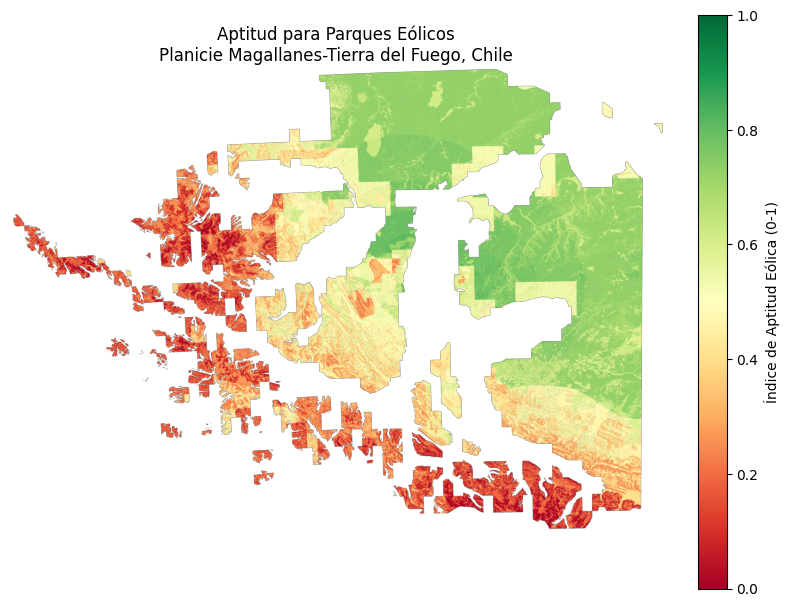

In [ ]:
# ============================================================
# Guardar y visualizar el mapa final
# ============================================================
import matplotlib.pyplot as plt

with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as ref:
    perfil_final = ref.profile.copy()
perfil_final.update({'dtype': 'float32', 'nodata': np.nan})

with rasterio.open(f'{carpeta}/aptitud_final_planicie.tif', 'w', **perfil_final) as dst:
    dst.write(aptitud_final_normalizada, 1)

fig, ax = plt.subplots(figsize=(8, 11))
im = ax.imshow(aptitud_final_normalizada, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.04, label='Índice de Aptitud Eólica (0-1)')
ax.set_title('Aptitud para Parques Eólicos\nPlanicie Magallanes-Tierra del Fuego, Chile')
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{carpeta}/aptitud_final_mapa.png', dpi=200, bbox_inches='tight')
plt.show()

In [2]:
import os
carpeta = '/content/drive/MyDrive/GEO3211_Eolico'
archivos = [f for f in os.listdir(carpeta) if f.endswith('.tif') or f.endswith('.shp')]
archivos.sort()
for a in archivos:
    print(a)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/GEO3211_Eolico'

In [ ]:
# ============================================================
# Descargar líneas de transmisión eléctrica desde IDE Energía
# (Ministerio de Energía / Coordinador Eléctrico Nacional)
# ============================================================
import geopandas as gpd

url_lineas = "https://ide-energia.minenergia.cl/server/rest/services/IDE_Energia/Visor_IDE_Energ%C3%ADa/FeatureServer/10/query?where=1%3D1&outFields=*&f=geojson"

lineas_chile = gpd.read_file(url_lineas)

print(f"Líneas encontradas: {len(lineas_chile)}")
print(f"CRS: {lineas_chile.crs}")
print(f"Columnas: {lineas_chile.columns.tolist()}")
print(f"\nSistemas eléctricos presentes:")
print(lineas_chile['SIST_ELECT'].value_counts())

Líneas encontradas: 1128
CRS: EPSG:4326
Columnas: ['OBJECTID', 'ID_LIN_TRANS', 'SUBTIPO', 'NOMBRE', 'CIRCUITO', 'TIPO', 'F_OPERACIO', 'LONG_KM', 'TRAMO', 'PROPIEDAD', 'TENSION_KV', 'RCA', 'SIST_ELECT', 'ESTADO', 'REGION', 'PROVINCIA', 'COMUNA', 'FUENTE_BAS', 'FECH_CREA', 'FECH_ACT', 'Shape__Length', 'geometry']

Sistemas eléctricos presentes:
SIST_ELECT
SEN    1111
SEA      16
SEM       1
Name: count, dtype: int64


In [ ]:
# ============================================================
# Variable 4: Redes Eléctricas — Descarga desde IDE Minenergia
# ============================================================
import requests
import geopandas as gpd

url_base = (
    "https://ide-energia.minenergia.cl/server/rest/services/"
    "IDE_Energia/Visor_IDE_Energ%C3%ADa/FeatureServer/10/query"
)

params = {
    'where': '1=1',
    'outFields': 'NOMBRE,SIST_ELECT,TENSION_KV',
    'f': 'geojson',
    'outSR': '32719',
    'resultOffset': 0,
    'resultRecordCount': 2000
}

print("Descargando líneas de transmisión...")
resp = requests.get(url_base, params=params, timeout=60)
resp.raise_for_status()

lineas = gpd.read_file(resp.text, driver='GeoJSON')
lineas = lineas.set_crs('EPSG:32719', allow_override=True)

print(f"✅ {len(lineas)} líneas descargadas")
print("Sistemas eléctricos:")
print(lineas['SIST_ELECT'].value_counts())

lineas.to_file(f'{carpeta}/lineas_transmision_planicie.shp')
print("✅ Guardado en Drive")

Descargando líneas de transmisión...


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


✅ 1128 líneas descargadas
Sistemas eléctricos:
SIST_ELECT
SEN    1111
SEA      16
SEM       1
Name: count, dtype: int64
✅ Guardado en Drive


In [ ]:
# ============================================================
# Variable 4: Distancia a redes eléctricas — Planicie Magallanes
# ============================================================
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.warp import transform as warp_transform
from scipy.ndimage import distance_transform_edt
import gc

# Grilla de referencia desde pendiente_planicie.tif
with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as ref:
    meta = ref.meta.copy()
    transform_ref = ref.transform
    shape_ref = ref.shape
    nodata_ref = ref.nodata
    mascara_valida = ref.read(1) != nodata_ref

pixel_size = abs(transform_ref.a)
print(f"Resolución pixel: {pixel_size:.1f} m")
print(f"Shape grilla:     {shape_ref}")

# Recortar líneas al bbox de la planicie (evita procesar todo Chile)
from shapely.geometry import box
bbox_planicie = box(
    transform_ref.c,
    transform_ref.f + transform_ref.e * shape_ref[0],
    transform_ref.c + transform_ref.a * shape_ref[1],
    transform_ref.f
)
lineas_clip = lineas[lineas.geometry.intersects(bbox_planicie)].copy()
print(f"Líneas en el área de estudio: {len(lineas_clip)}")

# Rasterizar líneas
shapes_lineas = (
    (geom, 1)
    for geom in lineas_clip.geometry
    if geom is not None and not geom.is_empty
)

raster_lineas = rasterize(
    shapes_lineas,
    out_shape=shape_ref,
    transform=transform_ref,
    fill=0,
    dtype='uint8'
)

print(f"Pixels con línea eléctrica: {raster_lineas.sum():,}")

# Distancia euclidiana en metros
dist_pixels = distance_transform_edt(raster_lineas == 0)
dist_metros = dist_pixels * pixel_size

print(f"Distancia mínima: {dist_metros[mascara_valida].min()/1000:.1f} km")
print(f"Distancia máxima: {dist_metros[mascara_valida].max()/1000:.1f} km")
print(f"Distancia media:  {dist_metros[mascara_valida].mean()/1000:.1f} km")

# Guardar distancia raw
meta.update(dtype='float32', nodata=-9999)
dist_out = np.where(mascara_valida, dist_metros.astype('float32'), -9999)

with rasterio.open(f'{carpeta}/distancia_red_electrica_planicie.tif', 'w', **meta) as dst:
    dst.write(dist_out, 1)

print("✅ distancia_red_electrica_planicie.tif guardado")

# Normalizar (más lejos = peor = invertir)
validos = dist_metros[mascara_valida]
vmin, vmax = validos.min(), validos.max()
dist_norm = np.where(mascara_valida,
                     1 - (dist_metros - vmin) / (vmax - vmin),
                     np.nan)

with rasterio.open(f'{carpeta}/aptitud_red_electrica_planicie.tif', 'w', **meta) as dst:
    out = np.where(mascara_valida, dist_norm.astype('float32'), -9999)
    dst.write(out, 1)

print("✅ aptitud_red_electrica_planicie.tif guardado")

del dist_pixels, raster_lineas
gc.collect()

Resolución pixel: 90.0 m
Shape grilla:     (3382, 4739)
Líneas en el área de estudio: 1
Pixels con línea eléctrica: 75
Distancia mínima: 0.0 km
Distancia máxima: 260.1 km
Distancia media:  115.2 km
✅ distancia_red_electrica_planicie.tif guardado
✅ aptitud_red_electrica_planicie.tif guardado


9006

In [ ]:
# ============================================================
# Recalcular aptitud_final_planicie con las 5 variables
# ============================================================
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import gc

def cargar_raster_remuestreado(path, ref_shape, ref_transform, ref_crs):
    with rasterio.open(path) as src:
        if src.shape == ref_shape:
            data = src.read(1).astype('float32')
            nodata = src.nodata
        else:
            print(f"   Remuestreando {path.split('/')[-1]}: {src.shape} → {ref_shape}")
            data = np.empty(ref_shape, dtype='float32')
            reproject(
                source=rasterio.band(src, 1),
                destination=data,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.bilinear
            )
            nodata = src.nodata
    if nodata is not None:
        return np.where(data == nodata, np.nan, data)
    return data

def rellenar_nan(arr):
    from scipy.ndimage import distance_transform_edt
    nan_mask = np.isnan(arr)
    if nan_mask.sum() == 0:
        return arr
    indices = distance_transform_edt(nan_mask, return_distances=False, return_indices=True)
    arr_filled = arr.copy()
    arr_filled[nan_mask] = arr[tuple(indices[:, nan_mask])]
    return arr_filled

def normalizar(arr, invertir=False):
    validos = arr[~np.isnan(arr)]
    vmin, vmax = validos.min(), validos.max()
    norm = (arr - vmin) / (vmax - vmin)
    return (1 - norm) if invertir else norm

# Grilla de referencia
with rasterio.open(f'{carpeta}/pendiente_planicie.tif') as ref:
    ref_shape     = ref.shape
    ref_transform = ref.transform
    ref_crs       = ref.crs
    ref_meta      = ref.meta.copy()

print(f"Grilla referencia: {ref_shape}")
print("Cargando 5 variables...")

# Cargar y rellenar viento (tiene NaN en bordes por resolución gruesa ERA5)
viento_raw = cargar_raster_remuestreado(
    f'{carpeta}/viento_planicie.tif', ref_shape, ref_transform, ref_crs)
viento_raw = rellenar_nan(viento_raw)

pendiente = cargar_raster_remuestreado(
    f'{carpeta}/pendiente_planicie.tif', ref_shape, ref_transform, ref_crs)
uso_suelo = cargar_raster_remuestreado(
    f'{carpeta}/aptitud_uso_suelo_planicie.tif', ref_shape, ref_transform, ref_crs)
ap = cargar_raster_remuestreado(
    f'{carpeta}/aptitud_snasp_planicie.tif', ref_shape, ref_transform, ref_crs)
distancia = cargar_raster_remuestreado(
    f'{carpeta}/distancia_red_electrica_planicie.tif', ref_shape, ref_transform, ref_crs)

print("Normalizando...")
viento_n    = normalizar(viento_raw,  invertir=False)
pendiente_n = normalizar(pendiente,   invertir=True)
uso_n       = normalizar(uso_suelo,   invertir=False)
ap_n        = ap.copy()
distancia_n = normalizar(distancia,   invertir=True)

print("NaN por capa tras normalizar:")
for nombre, arr in [('viento', viento_n), ('pendiente', pendiente_n),
                     ('uso_suelo', uso_n), ('ap', ap_n), ('distancia', distancia_n)]:
    print(f"  {nombre:12s}: {np.isnan(arr).sum():,} NaN")

# Máscara común
mascara = (
    ~np.isnan(viento_n)    &
    ~np.isnan(pendiente_n) &
    ~np.isnan(uso_n)       &
    ~np.isnan(ap_n)        &
    ~np.isnan(distancia_n)
)

# Pesos
pesos = {'viento': 0.35, 'pendiente': 0.20, 'uso_suelo': 0.15,
         'ap': 0.20, 'distancia': 0.10}

aptitud_final = (
    viento_n    * pesos['viento']    +
    pendiente_n * pesos['pendiente'] +
    uso_n       * pesos['uso_suelo'] +
    ap_n        * pesos['ap']        +
    distancia_n * pesos['distancia']
)
aptitud_final = np.where(mascara, aptitud_final, np.nan)

print(f"\n✅ Aptitud final calculada")
print(f"   Píxeles válidos: {mascara.sum():,}")
print(f"   Media:           {aptitud_final[mascara].mean():.3f}")
print(f"   Máximo:          {aptitud_final[mascara].max():.3f}")
print(f"   Mínimo:          {aptitud_final[mascara].min():.3f}")

# Guardar
ref_meta.update(dtype='float32', nodata=-9999)
out = np.where(mascara, aptitud_final.astype('float32'), -9999)

with rasterio.open(f'{carpeta}/aptitud_final_planicie.tif', 'w', **ref_meta) as dst:
    dst.write(out, 1)

print("✅ aptitud_final_planicie.tif guardado (sobreescrito con redes eléctricas incluidas)")

del viento_raw, pendiente, uso_suelo, ap, distancia
gc.collect()

Grilla referencia: (3382, 4739)
Cargando 5 variables...
   Remuestreando viento_planicie.tif: (28, 64) → (3382, 4739)
Normalizando...
NaN por capa tras normalizar:
  viento      : 0 NaN
  pendiente   : 9,223,015 NaN
  uso_suelo   : 8,881,123 NaN
  ap          : 8,881,123 NaN
  distancia   : 8,731,847 NaN

✅ Aptitud final calculada
   Píxeles válidos: 6,694,511
   Media:           1.181
   Máximo:          1.644
   Mínimo:          0.032
✅ aptitud_final_planicie.tif guardado (sobreescrito con redes eléctricas incluidas)


0

In [ ]:
# Diagnóstico rápido
for nombre, arr in [('viento_n', viento_n), ('pendiente_n', pendiente_n),
                     ('uso_n', uso_n), ('ap_n', ap_n), ('distancia_n', distancia_n)]:
    v = arr[~np.isnan(arr)]
    print(f"{nombre:15s}: min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}")

viento_n       : min=0.000  max=1.000  mean=0.514
pendiente_n    : min=0.000  max=1.000  mean=0.861
uso_n          : min=0.000  max=1.000  mean=0.583
ap_n           : min=0.000  max=5.000  mean=3.423
distancia_n    : min=0.000  max=1.000  mean=0.557


In [ ]:
# Recargar ap y recalcular
ap = cargar_raster_remuestreado(
    f'{carpeta}/aptitud_snasp_planicie.tif', ref_shape, ref_transform, ref_crs)

ap_n = normalizar(ap, invertir=False)

print("Verificación tras fix:")
for nombre, arr in [('viento_n', viento_n), ('pendiente_n', pendiente_n),
                     ('uso_n', uso_n), ('ap_n', ap_n), ('distancia_n', distancia_n)]:
    v = arr[~np.isnan(arr)]
    print(f"  {nombre:15s}: min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}")

# Recalcular
mascara = (
    ~np.isnan(viento_n)    &
    ~np.isnan(pendiente_n) &
    ~np.isnan(uso_n)       &
    ~np.isnan(ap_n)        &
    ~np.isnan(distancia_n)
)

pesos = {'viento': 0.35, 'pendiente': 0.20, 'uso_suelo': 0.15,
         'ap': 0.20, 'distancia': 0.10}

aptitud_final = (
    viento_n    * pesos['viento']    +
    pendiente_n * pesos['pendiente'] +
    uso_n       * pesos['uso_suelo'] +
    ap_n        * pesos['ap']        +
    distancia_n * pesos['distancia']
)
aptitud_final = np.where(mascara, aptitud_final, np.nan)

print(f"\n✅ Aptitud final recalculada")
print(f"   Píxeles válidos: {mascara.sum():,}")
print(f"   Media:           {aptitud_final[mascara].mean():.3f}")
print(f"   Máximo:          {aptitud_final[mascara].max():.3f}")
print(f"   Mínimo:          {aptitud_final[mascara].min():.3f}")

# Guardar
ref_meta.update(dtype='float32', nodata=-9999)
out = np.where(mascara, aptitud_final.astype('float32'), -9999)
with rasterio.open(f'{carpeta}/aptitud_final_planicie.tif', 'w', **ref_meta) as dst:
    dst.write(out, 1)

print("✅ aptitud_final_planicie.tif guardado correctamente")

Verificación tras fix:
  viento_n       : min=0.000  max=1.000  mean=0.514
  pendiente_n    : min=0.000  max=1.000  mean=0.861
  uso_n          : min=0.000  max=1.000  mean=0.583
  ap_n           : min=0.000  max=1.000  mean=0.685
  distancia_n    : min=0.000  max=1.000  mean=0.557

✅ Aptitud final recalculada
   Píxeles válidos: 6,694,511
   Media:           0.608
   Máximo:          0.844
   Mínimo:          0.032
✅ aptitud_final_planicie.tif guardado correctamente


In [ ]:
# ============================================================
# Fix: normalizar ap_n correctamente y recalcular
# ============================================================

# ap_n estaba en escala 0-5, normalizar a 0-1
ap_n = normalizar(ap, invertir=False)

print("Verificación tras fix:")
for nombre, arr in [('viento_n', viento_n), ('pendiente_n', pendiente_n),
                     ('uso_n', uso_n), ('ap_n', ap_n), ('distancia_n', distancia_n)]:
    v = arr[~np.isnan(arr)]
    print(f"  {nombre:15s}: min={v.min():.3f}  max={v.max():.3f}  mean={v.mean():.3f}")

# Recalcular máscara y aptitud final
mascara = (
    ~np.isnan(viento_n)    &
    ~np.isnan(pendiente_n) &
    ~np.isnan(uso_n)       &
    ~np.isnan(ap_n)        &
    ~np.isnan(distancia_n)
)

pesos = {'viento': 0.35, 'pendiente': 0.20, 'uso_suelo': 0.15,
         'ap': 0.20, 'distancia': 0.10}

aptitud_final = (
    viento_n    * pesos['viento']    +
    pendiente_n * pesos['pendiente'] +
    uso_n       * pesos['uso_suelo'] +
    ap_n        * pesos['ap']        +
    distancia_n * pesos['distancia']
)
aptitud_final = np.where(mascara, aptitud_final, np.nan)

print(f"\n✅ Aptitud final recalculada")
print(f"   Píxeles válidos: {mascara.sum():,}")
print(f"   Media:           {aptitud_final[mascara].mean():.3f}")
print(f"   Máximo:          {aptitud_final[mascara].max():.3f}")
print(f"   Mínimo:          {aptitud_final[mascara].min():.3f}")

# Guardar
ref_meta.update(dtype='float32', nodata=-9999)
out = np.where(mascara, aptitud_final.astype('float32'), -9999)
with rasterio.open(f'{carpeta}/aptitud_final_planicie.tif', 'w', **ref_meta) as dst:
    dst.write(out, 1)

print("✅ aptitud_final_planicie.tif guardado correctamente")

Verificación tras fix:
  viento_n       : min=0.000  max=1.000  mean=0.514
  pendiente_n    : min=0.000  max=1.000  mean=0.861
  uso_n          : min=0.000  max=1.000  mean=0.583
  ap_n           : min=0.000  max=1.000  mean=0.685
  distancia_n    : min=0.000  max=1.000  mean=0.557

✅ Aptitud final recalculada
   Píxeles válidos: 6,694,511
   Media:           0.608
   Máximo:          0.844
   Mínimo:          0.032
✅ aptitud_final_planicie.tif guardado correctamente


In [ ]:
!pip install matplotlib-scalebar -q

In [ ]:
# Mundo para Argentina — descarga directa desde Natural Earth
import requests, os

ne_path = f'{carpeta}/paises.geojson'
if not os.path.exists(ne_path):
    print("Descargando países desde Natural Earth...")
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
    r = requests.get(url, timeout=30)
    with open(ne_path, 'w') as f:
        f.write(r.text)
    print("✅ Descargado")

mundo     = gpd.read_file(ne_path).to_crs('EPSG:32719')
argentina = mundo[mundo['NAME'] == 'Argentina']
chile     = mundo[mundo['NAME'] == 'Chile']
print(f"Argentina: {len(argentina)} polígono(s)")
print(f"Chile:     {len(chile)} polígono(s)")

Argentina: 1 polígono(s)
Chile:     1 polígono(s)


In [ ]:
import geopandas as gpd
import requests, os

ne_path = f'{carpeta}/paises.geojson'
if not os.path.exists(ne_path):
    print("Descargando países...")
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
    r = requests.get(url, timeout=30)
    with open(ne_path, 'w') as f:
        f.write(r.text)
    print("✅ Descargado")

mundo     = gpd.read_file(ne_path).to_crs('EPSG:32719')
argentina = mundo[mundo['NAME'] == 'Argentina']
chile     = mundo[mundo['NAME'] == 'Chile']
print(f"Argentina: {len(argentina)} polígono(s)")
print(f"Chile:     {len(chile)} polígono(s)")

Argentina: 1 polígono(s)
Chile:     1 polígono(s)


In [ ]:
!pip install cartopy -q
import cartopy
print("✅ cartopy disponible")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 47.0 MB/s eta 0:00:00
✅ cartopy disponible


✅ Argentina: 1 pol. | Chile: 1 pol.


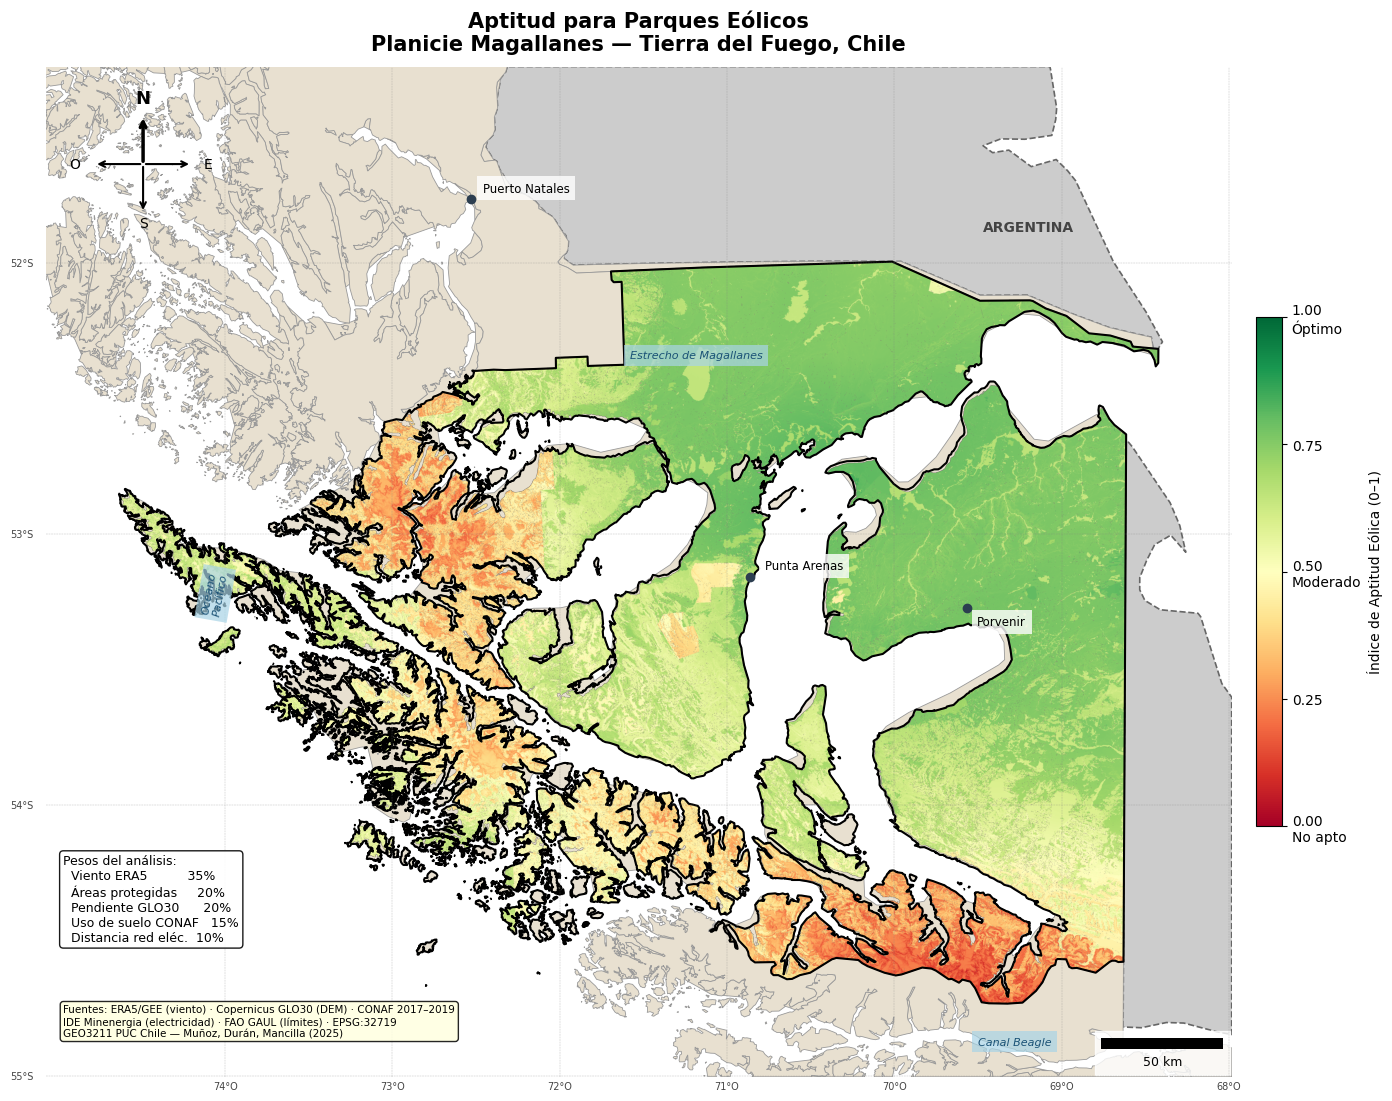

✅ mapa_cartografico_final_planicie.png guardado en Drive


In [ ]:
# ============================================================
# MAPA CARTOGRÁFICO FINAL v7 — corregido
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import transform as warp_transform
import geopandas as gpd
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.ops import unary_union
from shapely.geometry import box
import requests, os
import warnings
warnings.filterwarnings('ignore')

# --- Cargar datos ---
with rasterio.open(f'{carpeta}/aptitud_final_planicie.tif') as src:
    aptitud_plot = src.read(1).astype('float32')
    nodata = src.nodata if src.nodata is not None else -9999
    aptitud_plot = np.where(aptitud_plot == nodata, np.nan, aptitud_plot)
    bounds = src.bounds

planicie   = gpd.read_file(f'{carpeta}/planicie_limite.shp').to_crs('EPSG:32719')
magallanes = gpd.read_file(f'{carpeta}/magallanes_limite_limpio.shp').to_crs('EPSG:32719')

# Descargar países alta resolución (50m en vez de 110m)
ne_path = f'{carpeta}/paises_50m.geojson'
if not os.path.exists(ne_path):
    print("Descargando países 50m...")
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson"
    r = requests.get(url, timeout=60)
    with open(ne_path, 'w') as f:
        f.write(r.text)
    print("✅ Descargado")

mundo     = gpd.read_file(ne_path).to_crs('EPSG:32719')
argentina = mundo[mundo['NAME'] == 'Argentina']
chile     = mundo[mundo['NAME'] == 'Chile']
print(f"✅ Argentina: {len(argentina)} pol. | Chile: {len(chile)} pol.")

# --- Extent ---
margen   = 30000
margen_n = 80000
x_min = bounds.left  - margen
x_max = bounds.right + margen
y_min = bounds.bottom - margen
y_max = bounds.top + margen_n

# Bbox del extent para recortar países
bbox_extent = box(x_min, y_min, x_max, y_max)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_extent], crs='EPSG:32719')

# Recortar países al extent visible
argentina_clip = gpd.clip(argentina, bbox_gdf)
chile_clip     = gpd.clip(chile, bbox_gdf)
magallanes_clip = gpd.clip(magallanes, bbox_gdf)

# Restar planicie del fondo
planicie_union = unary_union(planicie.geometry)
mag_sin_planicie = magallanes_clip.copy()
mag_sin_planicie['geometry'] = magallanes_clip.geometry.difference(planicie_union)
mag_sin_planicie = mag_sin_planicie[~mag_sin_planicie.geometry.is_empty]

# Restar planicie y magallanes de Argentina (para que no tape el mar)
mag_union = unary_union(magallanes.geometry)
arg_sin_mag = argentina_clip.copy()
arg_sin_mag['geometry'] = argentina_clip.geometry.difference(mag_union)
arg_sin_mag = arg_sin_mag[~arg_sin_mag.geometry.is_empty]

chile_sin_mag = chile_clip.copy()
chile_sin_mag['geometry'] = chile_clip.geometry.difference(mag_union)
chile_sin_mag = chile_sin_mag[~chile_sin_mag.geometry.is_empty]

def geo_to_m(lon, lat):
    xs, ys = warp_transform('EPSG:4326', 'EPSG:32719', [lon], [lat])
    return xs[0], ys[0]

# --- Figura ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('#a8d4e6')   # mar azul
fig.patch.set_facecolor('white')

# 1. Argentina gris con borde punteado
arg_sin_mag.plot(ax=ax, color='#cccccc', edgecolor='#666666',
                 linewidth=1.2, linestyle='--', zorder=1)

# 2. Chile continental beige
chile_sin_mag.plot(ax=ax, color='#e8e0d0', edgecolor='#999999',
                   linewidth=0.6, zorder=2)

# 3. Magallanes sin planicie
mag_sin_planicie.plot(ax=ax, color='#e8e0d0', edgecolor='#999999',
                      linewidth=0.6, zorder=3)

# 4. Relleno beige dentro de planicie (cubre nodata/blancos)
planicie.plot(ax=ax, color='#e8e0d0', edgecolor='none', zorder=4)

# 5. Raster de aptitud
im = ax.imshow(aptitud_plot, cmap='RdYlGn', vmin=0, vmax=1,
               extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
               origin='upper', zorder=5)

# 6. Contorno área de estudio
planicie.boundary.plot(ax=ax, color='black', linewidth=1.5, zorder=6)

# --- Grilla en grados ---
for lon in [-74, -73, -72, -71, -70, -69, -68]:
    x_t, _ = geo_to_m(lon, -52)
    if x_min < x_t < x_max:
        ax.axvline(x=x_t, color='gray', linewidth=0.35, linestyle='--', alpha=0.5, zorder=7)
        ax.text(x_t, y_min - 5000, f'{abs(lon)}°O', ha='center', fontsize=7, color='#444')

for lat in [-51, -52, -53, -54, -55]:
    _, y_t = geo_to_m(-71, lat)
    if y_min < y_t < y_max:
        ax.axhline(y=y_t, color='gray', linewidth=0.35, linestyle='--', alpha=0.5, zorder=7)
        ax.text(x_min - 5000, y_t, f'{abs(lat)}°S', ha='right', va='center', fontsize=7, color='#444')

# --- Etiquetas geográficas ---
for (lon, lat, texto, rot) in [
    (-71.2, -52.35, 'Estrecho de Magallanes', 0),
    (-74.2, -53.2,  'Océano\nPacífico', 80),
    (-69.3, -54.9,  'Canal Beagle', 0),
]:
    x_t, y_t = geo_to_m(lon, lat)
    if x_min < x_t < x_max and y_min < y_t < y_max:
        ax.text(x_t, y_t, texto, ha='center', fontsize=8, fontstyle='italic',
                color='#1a5276', zorder=8, rotation=rot,
                bbox=dict(facecolor='#a8d4e6', alpha=0.7, edgecolor='none'))

# Argentina etiqueta
x_ar, y_ar = geo_to_m(-69.2, -51.9)
if x_min < x_ar < x_max and y_min < y_ar < y_max:
    ax.text(x_ar, y_ar, 'ARGENTINA', ha='center', fontsize=10,
            color='#444444', fontweight='bold', zorder=8,
            bbox=dict(facecolor='#cccccc', alpha=0.6, edgecolor='none'))

# Ciudades
for (lon, lat, nombre, dx, dy) in [
    (-70.91, -53.16, 'Punta Arenas',   6000,  3000),
    (-69.58, -53.29, 'Porvenir',       4000, -7000),
    (-72.51, -51.73, 'Puerto Natales', 5000,  3000),
]:
    x_t, y_t = geo_to_m(lon, lat)
    if x_min < x_t < x_max and y_min < y_t < y_max:
        ax.plot(x_t, y_t, 'o', color='#2c3e50', markersize=6, zorder=9)
        ax.text(x_t + dx, y_t + dy, nombre, fontsize=8.5, zorder=9,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# --- Extent ---
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect('equal')
ax.axis('off')

# --- Barra de color ---
cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                    fraction=0.022, pad=0.02, shrink=0.45)
cbar.set_label('Índice de Aptitud Eólica (0–1)', fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0.00\nNo apto', '0.25', '0.50\nModerado', '0.75', '1.00\nÓptimo'])

# --- Rosa de vientos ---
cx, cy = x_min + 40000, y_max - 40000
sz = 20000
ax.annotate('', xy=(cx, cy+sz), xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='black', lw=2.5), zorder=10)
ax.annotate('', xy=(cx, cy-sz), xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=10)
ax.annotate('', xy=(cx+sz, cy), xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=10)
ax.annotate('', xy=(cx-sz, cy), xytext=(cx, cy),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=10)
ax.text(cx, cy+sz+5000, 'N', ha='center', fontsize=13, fontweight='bold', zorder=10)
ax.text(cx, cy-sz-6000, 'S', ha='center', fontsize=10, zorder=10)
ax.text(cx+sz+5000, cy, 'E', ha='left',  va='center', fontsize=10, zorder=10)
ax.text(cx-sz-6000, cy, 'O', ha='right', va='center', fontsize=10, zorder=10)

# --- Escala ---
scalebar = ScaleBar(1, 'm', length_fraction=0.12, location='lower right',
                    pad=0.5, color='black', box_color='white', box_alpha=0.8,
                    font_properties={'size': 9})
ax.add_artist(scalebar)

# --- Leyenda pesos ---
leyenda = ("Pesos del análisis:\n"
           "  Viento ERA5          35%\n"
           "  Áreas protegidas     20%\n"
           "  Pendiente GLO30      20%\n"
           "  Uso de suelo CONAF   15%\n"
           "  Distancia red eléc.  10%")
ax.text(0.015, 0.22, leyenda, transform=ax.transAxes, fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9), zorder=10)

# --- Fuentes ---
ax.text(0.015, 0.04,
        "Fuentes: ERA5/GEE (viento) · Copernicus GLO30 (DEM) · CONAF 2017–2019\n"
        "IDE Minenergia (electricidad) · FAO GAUL (límites) · EPSG:32719\n"
        "GEO3211 PUC Chile — Muñoz, Durán, Mancilla (2025)",
        transform=ax.transAxes, fontsize=7.5,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85), zorder=10)

# --- Título ---
ax.set_title('Aptitud para Parques Eólicos\nPlanicie Magallanes — Tierra del Fuego, Chile',
             fontsize=15, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f'{carpeta}/mapa_cartografico_final_planicie.png', dpi=250, bbox_inches='tight')
plt.show()
print("✅ mapa_cartografico_final_planicie.png guardado en Drive")

Cargando capas...
   Remuestreando viento_planicie.tif: (28, 64) → (3382, 4739)
✅ Variables normalizadas


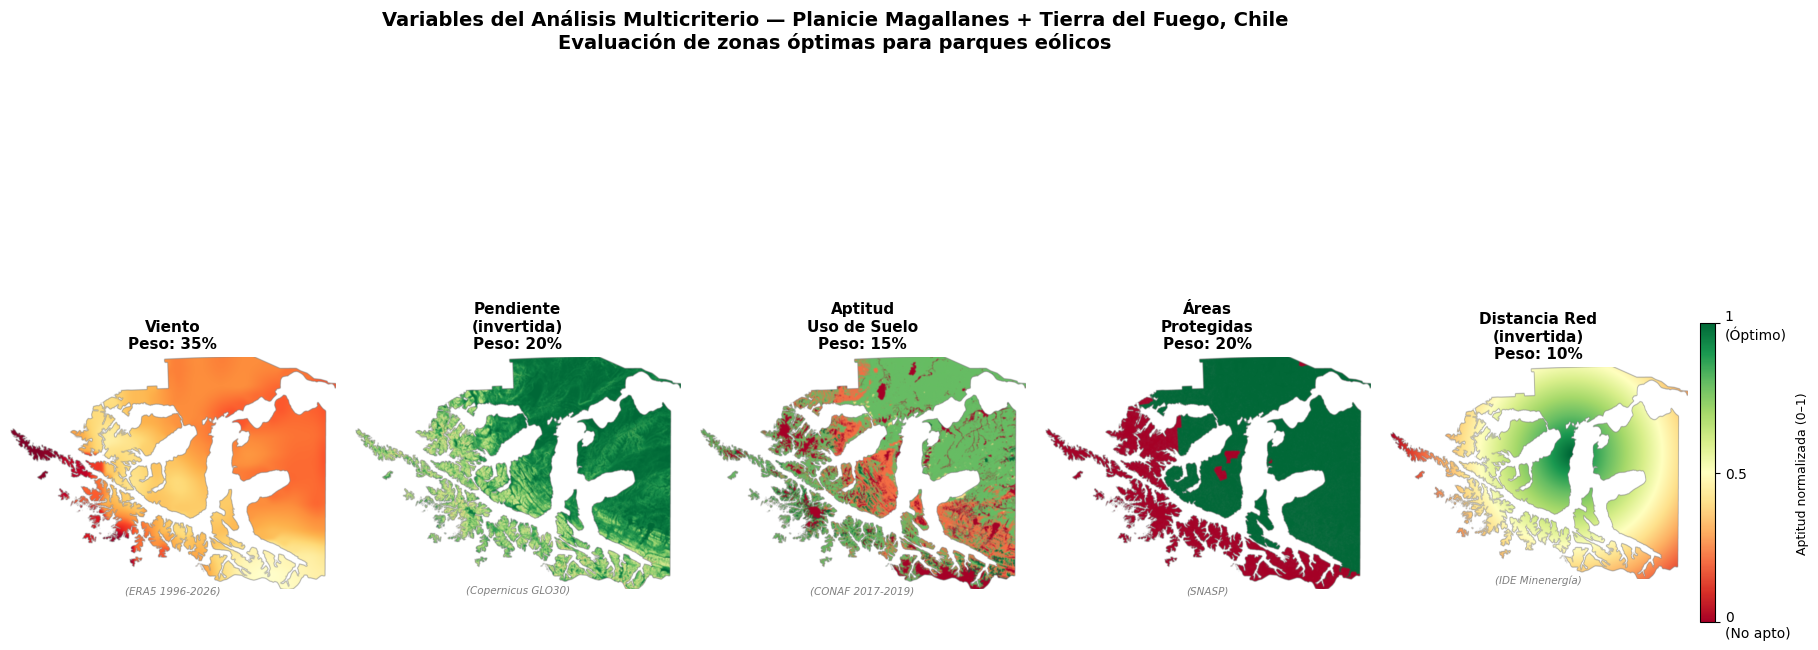

✅ cinco_variables_planicie_v3.png guardado


In [ ]:
# ============================================================
# FIGURA v3 — Variables AMC corregidas
# Viento suavizado + máscara + visualización mejorada
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import rasterio

from rasterio.warp import reproject, Resampling
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import gaussian_filter

# ============================================================
# FUNCIONES
# ============================================================

def cargar_raster_remuestreado(path, ref_shape, ref_transform, ref_crs):

    with rasterio.open(path) as src:

        if src.shape == ref_shape:

            data = src.read(1).astype("float32")
            nodata = src.nodata

        else:

            print(
                f"   Remuestreando {path.split('/')[-1]}: "
                f"{src.shape} → {ref_shape}"
            )

            data = np.empty(ref_shape, dtype="float32")

            reproject(
                source=rasterio.band(src, 1),
                destination=data,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.bilinear
            )

            nodata = src.nodata

    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)

    return data


def rellenar_nan(arr):

    nan_mask = np.isnan(arr)

    if nan_mask.sum() == 0:
        return arr

    indices = distance_transform_edt(
        nan_mask,
        return_distances=False,
        return_indices=True
    )

    arr_filled = arr.copy()
    arr_filled[nan_mask] = arr[tuple(indices[:, nan_mask])]

    return arr_filled


def normalizar(arr, invertir=False):

    validos = arr[~np.isnan(arr)]

    vmin = validos.min()
    vmax = validos.max()

    norm = (arr - vmin) / (vmax - vmin)

    if invertir:
        norm = 1 - norm

    return norm


# ============================================================
# GRILLA DE REFERENCIA
# ============================================================

with rasterio.open(
    f"{carpeta}/pendiente_planicie.tif"
) as ref:

    ref_shape = ref.shape
    ref_transform = ref.transform
    ref_crs = ref.crs


print("Cargando capas...")

# ============================================================
# CARGA DE DATOS
# ============================================================

viento_raw = cargar_raster_remuestreado(
    f"{carpeta}/viento_planicie.tif",
    ref_shape,
    ref_transform,
    ref_crs
)

pendiente = cargar_raster_remuestreado(
    f"{carpeta}/pendiente_planicie.tif",
    ref_shape,
    ref_transform,
    ref_crs
)

uso_suelo = cargar_raster_remuestreado(
    f"{carpeta}/aptitud_uso_suelo_planicie.tif",
    ref_shape,
    ref_transform,
    ref_crs
)

ap = cargar_raster_remuestreado(
    f"{carpeta}/aptitud_snasp_planicie.tif",
    ref_shape,
    ref_transform,
    ref_crs
)

distancia = cargar_raster_remuestreado(
    f"{carpeta}/distancia_red_electrica_planicie.tif",
    ref_shape,
    ref_transform,
    ref_crs
)

# ============================================================
# VIENTO
# ============================================================

viento_raw = rellenar_nan(viento_raw)

# Normalización REAL (para análisis)
viento_n = normalizar(viento_raw)

# ------------------------------------------------------------
# VERSIÓN VISUAL
# ------------------------------------------------------------
# sigma alto porque ERA5 es muy grueso
# solo para la figura
# ------------------------------------------------------------

viento_visual = gaussian_filter(
    viento_n,
    sigma=25
)

# ============================================================
# NORMALIZACIÓN RESTO VARIABLES
# ============================================================

pendiente_n = normalizar(
    pendiente,
    invertir=True
)

uso_n = normalizar(
    uso_suelo
)

ap_n = normalizar(
    ap
)

distancia_n = normalizar(
    distancia,
    invertir=True
)

# ============================================================
# MÁSCARA
# ============================================================

mask = ~np.isnan(pendiente)

viento_visual = np.where(
    mask,
    viento_visual,
    np.nan
)

pendiente_n = np.where(mask, pendiente_n, np.nan)
uso_n = np.where(mask, uso_n, np.nan)
ap_n = np.where(mask, ap_n, np.nan)
distancia_n = np.where(mask, distancia_n, np.nan)

print("✅ Variables normalizadas")

# ============================================================
# VARIABLES A GRAFICAR
# ============================================================

variables = [

    (
        viento_visual,
        "Viento",
        "YlOrRd",
        "(ERA5 1996-2026)",
        0.35
    ),

    (
        pendiente_n,
        "Pendiente\n(invertida)",
        "RdYlGn",
        "(Copernicus GLO30)",
        0.20
    ),

    (
        uso_n,
        "Aptitud\nUso de Suelo",
        "RdYlGn",
        "(CONAF 2017-2019)",
        0.15
    ),

    (
        ap_n,
        "Áreas\nProtegidas",
        "RdYlGn",
        "(SNASP)",
        0.20
    ),

    (
        distancia_n,
        "Distancia Red\n(invertida)",
        "RdYlGn",
        "(IDE Minenergía)",
        0.10
    ),
]

# ============================================================
# FIGURA
# ============================================================

fig = plt.figure(figsize=(22, 9))

gs = gridspec.GridSpec(
    1,
    5,
    figure=fig,
    wspace=0.06
)

for i, (arr, titulo, cmap, fuente, peso) in enumerate(variables):

    ax = fig.add_subplot(gs[i])

    # Bicubic solo para visualización
    im = ax.imshow(
        arr,
        cmap=cmap,
        vmin=0,
        vmax=1,
        interpolation="bicubic"
    )

    ax.set_title(
        f"{titulo}\nPeso: {int(peso*100)}%",
        fontsize=11,
        fontweight="bold",
        pad=6
    )

    ax.text(
        0.5,
        -0.02,
        fuente,
        transform=ax.transAxes,
        fontsize=7.5,
        ha="center",
        color="gray",
        style="italic"
    )

    ax.axis("off")

    if i == 4:

        cbar = fig.colorbar(
            im,
            ax=ax,
            orientation="vertical",
            fraction=0.046,
            pad=0.04,
            shrink=0.8
        )

        cbar.set_label(
            "Aptitud normalizada (0–1)",
            fontsize=9
        )

        cbar.set_ticks([0, 0.5, 1])

        cbar.set_ticklabels(
            [
                "0\n(No apto)",
                "0.5",
                "1\n(Óptimo)"
            ]
        )

# ============================================================
# TÍTULO
# ============================================================

fig.suptitle(
    "Variables del Análisis Multicriterio — "
    "Planicie Magallanes + Tierra del Fuego, Chile\n"
    "Evaluación de zonas óptimas para parques eólicos",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

# ============================================================
# EXPORTAR
# ============================================================

plt.savefig(
    f"{carpeta}/cinco_variables_planicie_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ cinco_variables_planicie_v3.png guardado")